## CSC-580 Default Final Project: Option 1 — World Model
### Name: Krishnarjun Lakshminarayanan
### Student ID: 2219738
### Reference - Gemini, Github

This notebook implements a **Dreamer V1**-style world model for the `highway-v0` environment from Gymnasium Highway-Env.

**Key Components:**
1. **Replay Buffer** — stores (frame, action, reward, next_frame, done) transitions
2. **World Dynamics Model** — Encoder, RSSM (GRU-based), Reward Head, Decoder
3. **Actor-Critic Model** — Policy (Actor) and Value (Critic) networks in latent space
4. **Dreamer Training Loop** — alternates world-model fitting, imagination, actor-critic updates, and real data collection
5. **Visualization & Evaluation** — side-by-side strips, alpha overlays, error heatmaps, MSE/PSNR/SSIM metrics

## 1. Installation & Google Drive Setup

In [ ]:
# Install required packages
import subprocess, sys

packages = [
    "gymnasium==0.29.1",
    "highway-env==1.10.2",
    "torch",
    "torchvision",
    "numpy",
    "matplotlib",
    "imageio",
    "opencv-python",
    "scikit-image",
    "tqdm",
    "pillow"
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages installed!")

All packages installed!


In [ ]:
# Mount Google Drive — all outputs save next to this notebook
from google.colab import drive
import os

drive.mount('/content/drive')
SAVE_DIR = '/content/drive/MyDrive/AI-2 Project/TinyDreamer_Output'
os.makedirs(SAVE_DIR, exist_ok=True)

def save_to_drive(local_path):
    import shutil
    dst = os.path.join(SAVE_DIR, os.path.basename(local_path))
    shutil.copy2(local_path, dst)
    print(f"  -> Saved to Drive: {dst}")

print(f"All outputs will be saved to: {SAVE_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All outputs will be saved to: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
import highway_env
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from collections import deque
import random
import cv2
import imageio
import shutil
import warnings
from tqdm.notebook import tqdm
from skimage.metrics import structural_similarity as ssim_metric
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from IPython.display import Image, display, HTML
from PIL import Image as PILImage
import io

warnings.filterwarnings('ignore')

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## 2. Environment Setup & Hyperparameters

Configure `highway-v0` with continuous actions and pixel rendering.

In [ ]:
# Hyperparameters

IMG_H, IMG_W = 64, 128          # Resized frame dimensions
IMG_C = 3                        # RGB channels

#  Latent space
LATENT_DIM = 256                 # Stochastic latent z  (was 64 - too small)
HIDDEN_DIM = 256                 # Deterministic GRU h  (was 128 - too small)
EMBED_DIM  = 512                 # Encoder output embedding

ACTION_DIM = 2                   # Continuous: [steering, acceleration]
SEQ_LEN = 32                     # Sequence length for training
BATCH_SIZE = 32                  # Reduced for memory safety on T4
IMAGINATION_HORIZON = 15         # Imagination rollout K steps
GAMMA = 0.99                     # Discount factor
LAMBDA_GAE = 0.95                # GAE lambda for value targets
LR_WORLD = 6e-4                  # World model learning rate
LR_ACTOR = 3e-4                  # Actor learning rate
LR_CRITIC = 3e-4                 # Critic learning rate
REPLAY_CAPACITY = 100000         # Replay buffer capacity (frames)
WARMUP_EPISODES = 5              # Random episodes for warmup

# Training + world model warmup
WM_WARMUP_STEPS = 300            # Extra world model pre-training steps
TRAIN_ITERATIONS = 100           # Main Dreamer loop iterations
WORLD_UPDATE_STEPS = 80          # World model gradient steps per iteration
ACTOR_CRITIC_STEPS = 30          # Actor-critic gradient steps per iteration
COLLECT_EPISODES = 2             # Episodes to collect per iteration
EVAL_EPISODES = 10               # Evaluation episodes

# KL hyperparameters
FREE_NATS = 0.0                  # Was 0.5 - way too high, killed the latent z
KL_WEIGHT = 1.0                  # Was 0.1 - too low, z was ignored
RECON_WEIGHT = 1.0               # Reconstruction loss weight
REWARD_WEIGHT = 2.0              # Reward loss weight
GRAD_CLIP = 100.0                # Gradient clipping

print("Hyperparameters configured.")
print(f"  Latent dims: z={LATENT_DIM}, h={HIDDEN_DIM}, embed={EMBED_DIM}")
print(f"  Decoder input size: {HIDDEN_DIM + LATENT_DIM} = {HIDDEN_DIM + LATENT_DIM} dims")
print(f"  Free nats: {FREE_NATS}, KL weight: {KL_WEIGHT}")

Hyperparameters configured.
  Latent dims: z=256, h=256, embed=512
  Decoder input size: 512 = 512 dims
  Free nats: 0.1, KL weight: 0.5


In [ ]:
def create_env(num_lanes=4):
    config = {
        "lanes_count": num_lanes,
        "vehicles_count": 30,
        "duration": 40,
        "policy_frequency": 2,
        "other_vehicles_type": "highway_env.vehicle.behavior.IDMVehicle",
        "screen_width": 600,
        "screen_height": 150,
        "offscreen_rendering": True,
        "action": {"type": "ContinuousAction"},
        "collision_reward": -5.0,
        "high_speed_reward": 0.2,
        "right_lane_reward": 0.1,
        "lane_change_reward": -0.05,
        "reward_speed_range": [23, 30],

    }
    env = gym.make("highway-v0", render_mode="rgb_array", config=config)
    return env

# Create and inspect
env = create_env()
obs, info = env.reset()
frame = env.render()

print(f"Observation shape (kinematics): {obs.shape}")
print(f"Action space: {env.action_space}")
print(f"Raw frame shape: {frame.shape}  dtype: {frame.dtype}")
print(f"Frame pixel range: [{frame.min()}, {frame.max()}]")

plt.figure(figsize=(10, 3))
plt.imshow(frame)
plt.title(f"Sample highway-v0 frame ({frame.shape[1]}x{frame.shape[0]})")
plt.axis('off')
plt.tight_layout()
plt.savefig('sample_frame.png', dpi=150, bbox_inches='tight')
save_to_drive('sample_frame.png')
plt.show()
plt.close()

Observation shape (kinematics): (5, 5)
Action space: Box(-1.0, 1.0, (2,), float32)
Raw frame shape: (150, 600, 3)  dtype: uint8
Frame pixel range: [0, 255]
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/sample_frame.png


In [ ]:
def preprocess_frame(frame):
    frame = cv2.resize(frame, (IMG_W, IMG_H), interpolation=cv2.INTER_AREA)
    frame = frame.astype(np.float32) / 255.0
    return frame  # (H, W, C)

def frame_to_tensor(frame):
    return torch.from_numpy(frame).permute(2, 0, 1)  # (C, H, W)

def tensor_to_frame(tensor):
    return tensor.detach().cpu().permute(1, 2, 0).clamp(0, 1).numpy()

# Test preprocessing
proc = preprocess_frame(frame)
print(f"Preprocessed frame: shape={proc.shape}, range=[{proc.min():.3f}, {proc.max():.3f}]")

# Verify round-trip
t = frame_to_tensor(proc)
back = tensor_to_frame(t)
print(f"Round-trip error: {np.abs(proc - back).max():.6f}")

Preprocessed frame: shape=(64, 128, 3), range=[0.000, 1.000]
Round-trip error: 0.000000


## 3. Replay Buffer

Episode-based storage with fixed-length sequence sampling for training the recurrent world model.

In [ ]:
class ReplayBuffer:

    def __init__(self, capacity=REPLAY_CAPACITY):
        self.capacity = capacity
        self.episodes = []
        self.total_frames = 0

    def add_episode(self, frames, actions, rewards, dones):
        ep = {
            'frames':  np.array(frames, dtype=np.float32),
            'actions': np.array(actions, dtype=np.float32),
            'rewards': np.array(rewards, dtype=np.float32),
            'dones':   np.array(dones, dtype=np.float32),
        }
        self.episodes.append(ep)
        self.total_frames += len(frames)
        while self.total_frames > self.capacity and len(self.episodes) > 1:
            removed = self.episodes.pop(0)
            self.total_frames -= len(removed['frames'])

    def sample_sequences(self, batch_size, seq_len):
        batch_frames, batch_actions, batch_rewards, batch_dones = [], [], [], []
        for _ in range(batch_size):
            valid = [ep for ep in self.episodes if len(ep['frames']) >= seq_len + 1]
            if not valid:
                valid = self.episodes
            ep = random.choice(valid)
            max_start = max(0, len(ep['frames']) - seq_len - 1)
            start = random.randint(0, max_start)
            batch_frames.append(ep['frames'][start:start+seq_len+1])
            batch_actions.append(ep['actions'][start:start+seq_len])
            batch_rewards.append(ep['rewards'][start:start+seq_len])
            batch_dones.append(ep['dones'][start:start+seq_len])
        return {
            'frames':  np.stack(batch_frames),
            'actions': np.stack(batch_actions),
            'rewards': np.stack(batch_rewards),
            'dones':   np.stack(batch_dones),
        }

    def __len__(self):
        return self.total_frames

replay_buffer = ReplayBuffer()
print("Replay buffer initialized.")

Replay buffer initialized.


## 4. World Dynamics Model

Following Dreamer V1 with architectural improvements:
- **Encoder**: CNN → FC embedding (512-dim bottleneck)
- **RSSM**: GRU with h=256, z=256 (larger latent space)
- **Decoder**: FC → transposed-CNN (512 total latent input)
- **Reward Model**: MLP from (h, z)

In [ ]:
# Encoder: CNN --> embedding vector
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: (3, 64, 128)
        self.convs = nn.Sequential(
            nn.Conv2d(IMG_C, 32, 4, stride=2, padding=1),   # -> (32, 32, 64)
            nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),      # -> (64, 16, 32)
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1),     # -> (128, 8, 16)
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, stride=2, padding=1),    # -> (256, 4, 8)
            nn.ReLU(),
        )
        self._conv_out_dim = 256 * 4 * 8
        # Bottleneck FC: 8192 -> EMBED_DIM (512)
        self.fc = nn.Sequential(
            nn.Linear(self._conv_out_dim, EMBED_DIM),
            nn.ReLU(),
        )
        self.embed_dim = EMBED_DIM

    def forward(self, x):
        h = self.convs(x)
        h = h.reshape(h.size(0), -1)
        return self.fc(h)



# Decoder: (h, z) --> reconstructed image
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()
        input_dim = HIDDEN_DIM + LATENT_DIM  # 256 + 256 = 512
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 256 * 4 * 8),
            nn.ReLU(),
        )
        self.deconvs = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),  # -> (128, 8, 16)
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),   # -> (64, 16, 32)
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),    # -> (32, 32, 64)
            nn.ReLU(),
            nn.ConvTranspose2d(32, IMG_C, 4, stride=2, padding=1), # -> (3, 64, 128)
            nn.Sigmoid(),
        )

    def forward(self, h, z):
        x = torch.cat([h, z], dim=-1)
        x = self.fc(x)
        x = x.reshape(-1, 256, 4, 8)
        return self.deconvs(x)



# RSSM: Recurrent State-Space Model
class RSSM(nn.Module):
    def __init__(self):
        super().__init__()
        # Input projection for GRU
        self.fc_input = nn.Sequential(
            nn.Linear(LATENT_DIM + ACTION_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        # GRU cell
        self.gru = nn.GRUCell(HIDDEN_DIM, HIDDEN_DIM)

        # Prior: h_t --> z_t prior
        self.fc_prior = nn.Sequential(
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        self.prior_mu  = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.prior_std = nn.Linear(HIDDEN_DIM, LATENT_DIM)

        # Posterior: (h_t, enc_embed) --> z_t posterior
        self.fc_posterior = nn.Sequential(
            nn.Linear(HIDDEN_DIM + EMBED_DIM, HIDDEN_DIM),
            nn.ReLU(),
            nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
            nn.ReLU(),
        )
        self.post_mu  = nn.Linear(HIDDEN_DIM, LATENT_DIM)
        self.post_std = nn.Linear(HIDDEN_DIM, LATENT_DIM)

    def initial_state(self, batch_size):
        h = torch.zeros(batch_size, HIDDEN_DIM, device=device)
        z = torch.zeros(batch_size, LATENT_DIM, device=device)
        return h, z

    def transition(self, h_prev, z_prev, action):
        x = self.fc_input(torch.cat([z_prev, action], dim=-1))
        h = self.gru(x, h_prev)
        return h

    def prior(self, h):
        x = self.fc_prior(h)
        mu  = self.prior_mu(x)
        std = F.softplus(self.prior_std(x)) + 1e-4
        return mu, std

    def posterior(self, h, enc_embed):
        x = torch.cat([h, enc_embed], dim=-1)
        x = self.fc_posterior(x)
        mu  = self.post_mu(x)
        std = F.softplus(self.post_std(x)) + 1e-4
        return mu, std

    def sample(self, mu, std):
        return Normal(mu, std).rsample()



# Reward Model: (h, z) --> predicted reward
class RewardModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(HIDDEN_DIM + LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, h, z):
        return self.net(torch.cat([h, z], dim=-1)).squeeze(-1)


print("World Dynamics model components defined.")
print(f"  Decoder input: {HIDDEN_DIM}(h) + {LATENT_DIM}(z) = {HIDDEN_DIM+LATENT_DIM} dimensions")

World Dynamics model components defined.
  Decoder input: 256(h) + 256(z) = 512 dimensions


## 5. Actor-Critic Model

Both operate entirely in latent space (h, z):
- **Actor**: tanh-squashed Gaussian policy
- **Critic**: state value estimator V(h, z)

In [ ]:
class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(HIDDEN_DIM + LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
        )
        self.mu_head  = nn.Linear(128, ACTION_DIM)
        self.std_head = nn.Linear(128, ACTION_DIM)

    def forward(self, h, z):
        x = self.net(torch.cat([h, z], dim=-1))
        mu  = self.mu_head(x)
        std = F.softplus(self.std_head(x)) + 1e-4
        dist = Normal(mu, std)
        raw = dist.rsample()
        action = torch.tanh(raw)
        log_prob = dist.log_prob(raw) - torch.log(1 - action.pow(2) + 1e-6)
        log_prob = log_prob.sum(-1)
        return action, log_prob

    def get_action(self, h, z, deterministic=False):
        x = self.net(torch.cat([h, z], dim=-1))
        mu = self.mu_head(x)
        if deterministic:
            return torch.tanh(mu)
        std = F.softplus(self.std_head(x)) + 1e-4
        return torch.tanh(Normal(mu, std).rsample())


class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(HIDDEN_DIM + LATENT_DIM, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
        )

    def forward(self, h, z):
        return self.net(torch.cat([h, z], dim=-1)).squeeze(-1)


print("Actor-Critic models defined.")

Actor-Critic models defined.


## 6. Instantiate Models & Optimizers

In [ ]:
encoder      = Encoder().to(device)
rssm         = RSSM().to(device)
decoder      = Decoder().to(device)
reward_model = RewardModel().to(device)
actor        = Actor().to(device)
critic       = Critic().to(device)

world_params = list(encoder.parameters()) + list(rssm.parameters()) + \
               list(decoder.parameters()) + list(reward_model.parameters())
world_optimizer  = optim.Adam(world_params, lr=LR_WORLD, eps=1e-5)
actor_optimizer  = optim.Adam(actor.parameters(), lr=LR_ACTOR, eps=1e-5)
critic_optimizer = optim.Adam(critic.parameters(), lr=LR_CRITIC, eps=1e-5)

n_world  = sum(p.numel() for p in world_params)
n_actor  = sum(p.numel() for p in actor.parameters())
n_critic = sum(p.numel() for p in critic.parameters())
print(f"Total parameters: {n_world + n_actor + n_critic:,}")
print(f"  World model:  {n_world:,}")
print(f"  Actor:        {n_actor:,}")
print(f"  Critic:       {n_critic:,}")

Total parameters: 11,389,257
  World model:  11,060,164
  Actor:        164,740
  Critic:       164,353


## 7. Data Collection

In [ ]:
def collect_episode(env, policy='random', max_steps=300):

    obs, info = env.reset()
    frame = preprocess_frame(env.render())

    frames  = [frame]
    actions = []
    rewards = []
    dones   = []

    if policy == 'actor':
        h, z = rssm.initial_state(1)

    for step in range(max_steps):
        if policy == 'random':
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                frame_t = frame_to_tensor(frame).unsqueeze(0).to(device)
                enc_embed = encoder(frame_t)
                if step > 0:
                    a_prev = torch.tensor(actions[-1], dtype=torch.float32, device=device).unsqueeze(0)
                    h = rssm.transition(h, z, a_prev)
                post_mu, post_std = rssm.posterior(h, enc_embed)
                z = rssm.sample(post_mu, post_std)
                action = actor.get_action(h, z, deterministic=False)
                action = action.squeeze(0).cpu().numpy()

        obs, reward, terminated, truncated, info = env.step(action)
        frame = preprocess_frame(env.render())

        actions.append(np.array(action, dtype=np.float32).flatten())
        rewards.append(float(reward))
        dones.append(float(terminated or truncated))
        frames.append(frame)

        if terminated or truncated:
            break

    return frames, actions, rewards, dones

print("Collection function defined.")

Collection function defined.


## 8. Phase 0 — Warm-up Exploration

Collect random episodes to seed the replay buffer.

In [ ]:
print(f"Collecting {WARMUP_EPISODES} warm-up episodes with random actions...")
warmup_rewards = []
for ep in range(WARMUP_EPISODES):
    frames, actions, rewards, dones = collect_episode(env, policy='random')
    replay_buffer.add_episode(frames, actions, rewards, dones)
    ep_reward = sum(rewards)
    warmup_rewards.append(ep_reward)
    print(f"  Episode {ep+1}: reward={ep_reward:.2f}, steps={len(actions)}, frames={len(frames)}")

print(f"\nReplay buffer: {len(replay_buffer)} frames, {len(replay_buffer.episodes)} episodes")
print(f"Average random reward: {np.mean(warmup_rewards):.2f}")

  Episode 1: reward=3.81, steps=80, frames=81
  Episode 2: reward=18.03, steps=80, frames=81
  Episode 3: reward=10.48, steps=80, frames=81
  Episode 4: reward=0.95, steps=80, frames=81
  Episode 5: reward=3.82, steps=80, frames=81

Replay buffer: 405 frames, 5 episodes
Average random reward: 7.42


## 9a. World Model Training Function

Loss = recon_weight * reconstruction + reward_weight * reward_pred + kl_weight * KL

Key fixes from previous version:
- Free nats lowered to 0.1 (was 1.0 — blocked z from learning)
- KL weight increased to 0.5 (was 0.1 — z was ignored)
- Reward weight 2.0 to emphasize reward signal

In [ ]:
def train_world_model(num_steps, return_recon_samples=False):
    encoder.train(); rssm.train(); decoder.train(); reward_model.train()

    total_loss_sum = 0
    recon_loss_sum = 0
    reward_loss_sum = 0
    kl_loss_sum = 0
    samples = None

    for step_i in range(num_steps):
        batch = replay_buffer.sample_sequences(BATCH_SIZE, SEQ_LEN)

        # (B, T+1, H, W, C) -> (B, T+1, C, H, W)
        frames_t = torch.from_numpy(batch['frames']).permute(0, 1, 4, 2, 3).to(device)
        actions_t = torch.from_numpy(batch['actions']).to(device)
        rewards_t = torch.from_numpy(batch['rewards']).to(device)

        B, T = actions_t.shape[0], actions_t.shape[1]
        h, z = rssm.initial_state(B)

        recon_loss = 0
        reward_loss = 0
        kl_loss = 0

        for t in range(T):
            enc_embed = encoder(frames_t[:, t])
            if t > 0:
                h = rssm.transition(h, z, actions_t[:, t-1])

            prior_mu, prior_std = rssm.prior(h)
            post_mu, post_std   = rssm.posterior(h, enc_embed)
            z = rssm.sample(post_mu, post_std)

            # Decode
            recon = decoder(h, z)
            recon_loss += F.mse_loss(recon, frames_t[:, t], reduction='mean')

            # Reward
            pred_rew = reward_model(h, z)
            reward_loss += F.mse_loss(pred_rew, rewards_t[:, t], reduction='mean')

            # KL with free nats
            kl = torch.distributions.kl_divergence(
                Normal(post_mu, post_std), Normal(prior_mu, prior_std)
            ).sum(-1).mean()
            kl = torch.clamp(kl, min=FREE_NATS)
            kl_loss += kl

        # Average over time steps
        recon_loss  /= T
        reward_loss /= T
        kl_loss     /= T

        loss = RECON_WEIGHT * recon_loss + REWARD_WEIGHT * reward_loss + KL_WEIGHT * kl_loss

        world_optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(world_params, GRAD_CLIP)
        world_optimizer.step()

        total_loss_sum  += loss.item()
        recon_loss_sum  += recon_loss.item()
        reward_loss_sum += reward_loss.item()
        kl_loss_sum     += kl_loss.item()

        # Capture last-step reconstruction for visualization
        if return_recon_samples and step_i == num_steps - 1:
            with torch.no_grad():
                samples = {
                    'gt': frames_t[0, T//2].cpu(),
                    'recon': recon[0].cpu(),
                }

    n = num_steps
    result = {
        'total': total_loss_sum / n,
        'recon': recon_loss_sum / n,
        'reward': reward_loss_sum / n,
        'kl': kl_loss_sum / n,
    }
    if return_recon_samples:
        result['samples'] = samples
    return result

print("World model training function defined.")

World model training function defined.


## 9b. World Model Warmup

Pre-train the world model before starting actor-critic, so the decoder can actually reconstruct frames.

In [ ]:
print(f"World model warmup: {WM_WARMUP_STEPS} gradient steps...")
warmup_losses = train_world_model(WM_WARMUP_STEPS, return_recon_samples=True)
print(f"  Warmup done: recon={warmup_losses['recon']:.4f}, reward={warmup_losses['reward']:.4f}, kl={warmup_losses['kl']:.4f}")

# Show reconstruction quality after warmup
if warmup_losses.get('samples'):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    gt_img = warmup_losses['samples']['gt'].permute(1, 2, 0).clamp(0, 1).numpy()
    recon_img = warmup_losses['samples']['recon'].permute(1, 2, 0).clamp(0, 1).numpy()
    axes[0].imshow(gt_img); axes[0].set_title('Ground Truth'); axes[0].axis('off')
    axes[1].imshow(recon_img); axes[1].set_title('Reconstruction (after warmup)'); axes[1].axis('off')
    plt.suptitle('World Model Warmup — Reconstruction Check', fontweight='bold')
    plt.tight_layout()
    plt.savefig('warmup_recon_check.png', dpi=150, bbox_inches='tight')
    save_to_drive('warmup_recon_check.png')
    plt.show()
    plt.close()

World model warmup: 300 gradient steps...
  Warmup done: recon=0.0020, reward=0.0806, kl=0.1108
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/warmup_recon_check.png


## 10. Imagination & Actor-Critic Training

In [ ]:
def compute_lambda_returns(rewards, values, gamma=GAMMA, lam=LAMBDA_GAE):
    K = rewards.shape[0]
    returns = torch.zeros_like(rewards)
    last = values[-1]
    for t in reversed(range(K)):
        returns[t] = rewards[t] + gamma * ((1 - lam) * values[t + 1] + lam * last)
        last = returns[t]
    return returns


def train_actor_critic(num_steps=ACTOR_CRITIC_STEPS):
    encoder.eval(); rssm.eval(); reward_model.eval()
    actor.train(); critic.train()

    actor_loss_sum = 0
    critic_loss_sum = 0

    for _ in range(num_steps):
        batch = replay_buffer.sample_sequences(BATCH_SIZE, SEQ_LEN)
        frames_t = torch.from_numpy(batch['frames']).permute(0, 1, 4, 2, 3).to(device)
        actions_t = torch.from_numpy(batch['actions']).to(device)
        B = actions_t.shape[0]

        # Build starting latent state from real data
        with torch.no_grad():
            h, z = rssm.initial_state(B)
            start_t = random.randint(0, SEQ_LEN - 1)
            for t in range(start_t + 1):
                enc_embed = encoder(frames_t[:, t])
                if t > 0:
                    h = rssm.transition(h, z, actions_t[:, t-1])
                post_mu, post_std = rssm.posterior(h, enc_embed)
                z = rssm.sample(post_mu, post_std)

        # Imagination rollout
        imag_h_list = [h]
        imag_z_list = [z]
        imag_rewards = []

        h_imag, z_imag = h, z
        for k in range(IMAGINATION_HORIZON):
            action_imag, _ = actor(h_imag, z_imag)
            h_imag = rssm.transition(h_imag, z_imag, action_imag)
            prior_mu, prior_std = rssm.prior(h_imag)
            z_imag = rssm.sample(prior_mu, prior_std)
            r_imag = reward_model(h_imag, z_imag)
            imag_h_list.append(h_imag)
            imag_z_list.append(z_imag)
            imag_rewards.append(r_imag)

        imag_rewards = torch.stack(imag_rewards)  # (K, B)

        imag_values = torch.stack([
            critic(imag_h_list[k], imag_z_list[k]) for k in range(IMAGINATION_HORIZON + 1)
        ])  # (K+1, B)

        lambda_returns = compute_lambda_returns(imag_rewards, imag_values.detach())

        # Critic loss
        critic_loss = 0.5 * F.mse_loss(imag_values[:-1], lambda_returns.detach())
        critic_optimizer.zero_grad()
        critic_loss.backward(retain_graph=True)
        nn.utils.clip_grad_norm_(critic.parameters(), GRAD_CLIP)
        critic_optimizer.step()

        # Actor loss
        actor_loss = -lambda_returns.mean()
        actor_optimizer.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(actor.parameters(), GRAD_CLIP)
        actor_optimizer.step()

        actor_loss_sum  += actor_loss.item()
        critic_loss_sum += critic_loss.item()

    n = num_steps
    return {'actor_loss': actor_loss_sum / n, 'critic_loss': critic_loss_sum / n}

print("Actor-Critic training function defined.")

Actor-Critic training function defined.


## 11. Evaluation Function

In [ ]:
def evaluate_policy(env, num_episodes=EVAL_EPISODES, deterministic=True):
    encoder.eval(); rssm.eval(); actor.eval()
    ep_rewards, ep_lengths = [], []
    collisions = 0
    speeds = []

    for _ in range(num_episodes):
        obs, info = env.reset()
        frame = preprocess_frame(env.render())
        h, z = rssm.initial_state(1)
        total_reward = 0
        prev_action = None

        for step in range(300):
            with torch.no_grad():
                frame_t = frame_to_tensor(frame).unsqueeze(0).to(device)
                enc_embed = encoder(frame_t)
                if step > 0 and prev_action is not None:
                    a_prev = torch.tensor(prev_action, dtype=torch.float32, device=device).unsqueeze(0)
                    h = rssm.transition(h, z, a_prev)
                post_mu, post_std = rssm.posterior(h, enc_embed)
                z = rssm.sample(post_mu, post_std)
                action = actor.get_action(h, z, deterministic=deterministic)
                action = action.squeeze(0).cpu().numpy()

            obs, reward, terminated, truncated, info = env.step(action)
            frame = preprocess_frame(env.render())
            prev_action = action
            total_reward += reward

            try:
                speeds.append(env.unwrapped.vehicle.speed)
            except:
                pass

            if terminated:
                collisions += 1
                break
            if truncated:
                break

        ep_rewards.append(total_reward)
        ep_lengths.append(step + 1)

    return {
        'mean_reward': np.mean(ep_rewards),
        'std_reward': np.std(ep_rewards),
        'mean_length': np.mean(ep_lengths),
        'collision_rate': collisions / num_episodes,
        'mean_speed': np.mean(speeds) if speeds else 0,
        'rewards': ep_rewards,
    }

print("Evaluation function defined.")

Evaluation function defined.


## 12. Main Dreamer Training Loop


In [ ]:
history = {
    'world_total': [], 'world_recon': [], 'world_reward': [], 'world_kl': [],
    'actor_loss': [], 'critic_loss': [],
    'eval_reward': [], 'eval_collision': [], 'eval_speed': [],
    'collect_reward': [],
}

eval_interval = 10
save_interval = 20  # Save checkpoint to Drive every N iters

print(f"Starting Dreamer training for {TRAIN_ITERATIONS} iterations...")
print(f"  World model steps/iter: {WORLD_UPDATE_STEPS}")
print(f"  Actor-Critic steps/iter: {ACTOR_CRITIC_STEPS}")
print(f"  Collection episodes/iter: {COLLECT_EPISODES}")
print(f"  Eval every {eval_interval} iters | Checkpoint every {save_interval} iters")
print("=" * 70)

for iteration in tqdm(range(1, TRAIN_ITERATIONS + 1), desc="Dreamer Training"):
    # Phase 1: World model update
    wm_losses = train_world_model(WORLD_UPDATE_STEPS)
    history['world_total'].append(wm_losses['total'])
    history['world_recon'].append(wm_losses['recon'])
    history['world_reward'].append(wm_losses['reward'])
    history['world_kl'].append(wm_losses['kl'])

    # Phase 2: Actor-Critic update (imagination)
    ac_losses = train_actor_critic(ACTOR_CRITIC_STEPS)
    history['actor_loss'].append(ac_losses['actor_loss'])
    history['critic_loss'].append(ac_losses['critic_loss'])

    # Phase 3: Collect new real data
    collect_rewards = []
    for _ in range(COLLECT_EPISODES):
        frames, actions, rewards, dones = collect_episode(env, policy='actor')
        replay_buffer.add_episode(frames, actions, rewards, dones)
        collect_rewards.append(sum(rewards))
    history['collect_reward'].append(np.mean(collect_rewards))

    # Evaluation
    if iteration % eval_interval == 0 or iteration == 1:
        eval_result = evaluate_policy(env, num_episodes=EVAL_EPISODES)
        history['eval_reward'].append(eval_result['mean_reward'])
        history['eval_collision'].append(eval_result['collision_rate'])
        history['eval_speed'].append(eval_result['mean_speed'])

        print(f"\n[Iter {iteration:3d}] WM: recon={wm_losses['recon']:.4f} rew={wm_losses['reward']:.4f} kl={wm_losses['kl']:.3f} | "
              f"Actor={ac_losses['actor_loss']:.3f} Critic={ac_losses['critic_loss']:.3f} | "
              f"Eval: {eval_result['mean_reward']:.1f}+/-{eval_result['std_reward']:.1f} "
              f"Coll={eval_result['collision_rate']:.0%} Spd={eval_result['mean_speed']:.1f}")

    # Periodic checkpoint save to Drive
    if iteration % save_interval == 0:
        ckpt_path = f'checkpoint_iter{iteration}.pt'
        torch.save({
            'iteration': iteration,
            'encoder': encoder.state_dict(),
            'rssm': rssm.state_dict(),
            'decoder': decoder.state_dict(),
            'reward_model': reward_model.state_dict(),
            'actor': actor.state_dict(),
            'critic': critic.state_dict(),
            'history': history,
        }, ckpt_path)
        save_to_drive(ckpt_path)

print("\nTraining complete!")
print(f"Replay buffer: {len(replay_buffer)} frames")

# Final checkpoint
torch.save({
    'encoder': encoder.state_dict(), 'rssm': rssm.state_dict(),
    'decoder': decoder.state_dict(), 'reward_model': reward_model.state_dict(),
    'actor': actor.state_dict(), 'critic': critic.state_dict(),
    'history': history,
}, 'tiny_dreamer_final.pt')
save_to_drive('tiny_dreamer_final.pt')

Starting Dreamer training for 100 iterations...
  World model steps/iter: 80
  Actor-Critic steps/iter: 30
  Collection episodes/iter: 2
  Eval every 10 iters | Checkpoint every 20 iters


Dreamer Training:   0%|          | 0/100 [00:00<?, ?it/s]


[Iter   1] WM: recon=0.0010 rew=0.0580 kl=0.100 | Actor=-5.385 Critic=14.911 | Eval: 4.7+/-1.8 Coll=0% Spd=-28.3

[Iter  10] WM: recon=0.0018 rew=0.1533 kl=0.100 | Actor=-43.958 Critic=7.823 | Eval: 15.5+/-12.8 Coll=0% Spd=-28.9

[Iter  20] WM: recon=0.0019 rew=0.1793 kl=0.100 | Actor=-39.893 Critic=3.803 | Eval: 17.6+/-14.9 Coll=0% Spd=-19.5
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter20.pt

[Iter  30] WM: recon=0.0019 rew=0.1748 kl=0.100 | Actor=-45.878 Critic=6.145 | Eval: 50.7+/-28.5 Coll=0% Spd=-28.9

[Iter  40] WM: recon=0.0021 rew=0.1826 kl=0.100 | Actor=-62.609 Critic=11.828 | Eval: 30.9+/-20.9 Coll=0% Spd=-27.5
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter40.pt

[Iter  50] WM: recon=0.0022 rew=0.1866 kl=0.100 | Actor=-59.204 Critic=4.641 | Eval: 47.8+/-25.9 Coll=0% Spd=-29.0

[Iter  60] WM: recon=0.0023 rew=0.1894 kl=0.100 | Actor=-44.504 Critic=7.273 | Eval: 45.0+/-27.8 Coll=0% Spd=-

## 13. Learning Curves

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0, 0].plot(history['world_recon'], alpha=0.8)
axes[0, 0].set_title('Reconstruction Loss (MSE)', fontweight='bold')
axes[0, 0].set_xlabel('Iteration'); axes[0, 0].set_ylabel('Loss'); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(history['world_reward'], color='orange', alpha=0.8)
axes[0, 1].set_title('Reward Prediction Loss (MSE)', fontweight='bold')
axes[0, 1].set_xlabel('Iteration'); axes[0, 1].set_ylabel('Loss'); axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(history['world_kl'], color='green', alpha=0.8)
axes[0, 2].axhline(y=FREE_NATS, color='red', linestyle='--', alpha=0.5, label=f'Free nats={FREE_NATS}')
axes[0, 2].set_title('KL Divergence', fontweight='bold')
axes[0, 2].set_xlabel('Iteration'); axes[0, 2].set_ylabel('KL (nats)'); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(history['actor_loss'], color='red', alpha=0.8, label='Actor')
axes[1, 0].plot(history['critic_loss'], color='blue', alpha=0.8, label='Critic')
axes[1, 0].set_title('Actor-Critic Losses', fontweight='bold')
axes[1, 0].set_xlabel('Iteration'); axes[1, 0].legend(); axes[1, 0].grid(True, alpha=0.3)

eval_iters = list(range(0, len(history['eval_reward']) * eval_interval, eval_interval))
if len(eval_iters) > len(history['eval_reward']):
    eval_iters = eval_iters[:len(history['eval_reward'])]
axes[1, 1].plot(eval_iters, history['eval_reward'], 'g-o', markersize=4)
axes[1, 1].set_title('Evaluation: Mean Reward', fontweight='bold')
axes[1, 1].set_xlabel('Iteration'); axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].plot(history['collect_reward'], color='purple', alpha=0.4)
if len(history['collect_reward']) > 5:
    smoothed = np.convolve(history['collect_reward'], np.ones(5)/5, mode='valid')
    axes[1, 2].plot(range(4, len(history['collect_reward'])), smoothed, color='purple', linewidth=2)
axes[1, 2].set_title('Collection Reward (per iteration)', fontweight='bold')
axes[1, 2].set_xlabel('Iteration'); axes[1, 2].grid(True, alpha=0.3)

plt.suptitle('Tiny Dreamer — Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
save_to_drive('learning_curves.png')
plt.show()
plt.close()

  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/learning_curves.png


## 14. Reconstruction Quality Check

Verify the decoder can actually reconstruct highway frames with vehicles visible.

In [ ]:
# Reconstruct a few frames from a real episode to verify quality
encoder.eval(); rssm.eval(); decoder.eval()

batch = replay_buffer.sample_sequences(1, SEQ_LEN)
frames_t = torch.from_numpy(batch['frames']).permute(0, 1, 4, 2, 3).to(device)
actions_t = torch.from_numpy(batch['actions']).to(device)

h, z = rssm.initial_state(1)
recons = []
gts = []

with torch.no_grad():
    for t in range(SEQ_LEN):
        enc_embed = encoder(frames_t[:, t])
        if t > 0:
            h = rssm.transition(h, z, actions_t[:, t-1])
        post_mu, post_std = rssm.posterior(h, enc_embed)
        z = rssm.sample(post_mu, post_std)
        recon = decoder(h, z)
        recons.append(tensor_to_frame(recon[0]))
        gts.append(tensor_to_frame(frames_t[0, t]))

# Show 8 evenly spaced frames
show_idxs = np.linspace(0, SEQ_LEN-1, 8, dtype=int)
fig, axes = plt.subplots(3, 8, figsize=(20, 7))

for i, idx in enumerate(show_idxs):
    axes[0, i].imshow(gts[idx]); axes[0, i].axis('off'); axes[0, i].set_title(f't={idx}', fontsize=9)
    axes[1, i].imshow(recons[idx]); axes[1, i].axis('off')
    error = np.abs(gts[idx].astype(float) - recons[idx].astype(float)).mean(axis=-1)
    axes[2, i].imshow(error, cmap='hot', vmin=0, vmax=0.3); axes[2, i].axis('off')

axes[0, 0].set_ylabel('Ground Truth', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Reconstruction', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Error', fontsize=11, fontweight='bold')

plt.suptitle('Reconstruction Quality: Posterior z (with observation)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reconstruction_quality.png', dpi=150, bbox_inches='tight')
save_to_drive('reconstruction_quality.png')
plt.show()
plt.close()
print("Reconstruction check saved.")

  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/reconstruction_quality.png
Reconstruction check saved.


## 15. N-step Prediction Visualization

Multi-step predictions using only the **prior** (no observation updates):
- Side-by-side strips: GT | Predicted | Error heatmap
- Alpha overlays for spatial drift
- Error-vs-horizon: MSE/PSNR/SSIM

In [ ]:
def generate_nstep_predictions(env, K=15, context=5):
    encoder.eval(); rssm.eval(); decoder.eval(); actor.eval()

    obs, info = env.reset()
    all_frames = [preprocess_frame(env.render())]
    all_actions = []

    h, z = rssm.initial_state(1)

    # Collect context + K frames using actor
    needed = context + K + 1
    for step in range(needed):
        with torch.no_grad():
            frame_t = frame_to_tensor(all_frames[-1]).unsqueeze(0).to(device)
            enc_embed = encoder(frame_t)
            if step > 0:
                a_prev = torch.tensor(all_actions[-1], dtype=torch.float32, device=device).unsqueeze(0)
                h = rssm.transition(h, z, a_prev)
            post_mu, post_std = rssm.posterior(h, enc_embed)
            z = rssm.sample(post_mu, post_std)
            action = actor.get_action(h, z, deterministic=True).squeeze(0).cpu().numpy()

        obs, _, terminated, truncated, _ = env.step(action)
        all_frames.append(preprocess_frame(env.render()))
        all_actions.append(action)
        if terminated or truncated:
            break

    if len(all_frames) < context + K:
        print(f"Warning: episode too short ({len(all_frames)} frames), reducing K")
        K = len(all_frames) - context - 1
        if K < 1:
            return [], []

    # Infer latent state from context frames
    with torch.no_grad():
        h, z = rssm.initial_state(1)
        for t in range(context):
            frame_t = frame_to_tensor(all_frames[t]).unsqueeze(0).to(device)
            enc_embed = encoder(frame_t)
            if t > 0:
                a_prev = torch.tensor(all_actions[t-1], dtype=torch.float32, device=device).unsqueeze(0)
                h = rssm.transition(h, z, a_prev)
            post_mu, post_std = rssm.posterior(h, enc_embed)
            z = rssm.sample(post_mu, post_std)

        # Open-loop prediction: K steps using prior only
        pred_frames = []
        for k in range(K):
            a_idx = context + k - 1
            if a_idx < len(all_actions):
                a = torch.tensor(all_actions[a_idx], dtype=torch.float32, device=device).unsqueeze(0)
            else:
                a = torch.zeros(1, ACTION_DIM, device=device)
            h = rssm.transition(h, z, a)
            prior_mu, prior_std = rssm.prior(h)
            z = rssm.sample(prior_mu, prior_std)
            recon = decoder(h, z)
            pred_frames.append(tensor_to_frame(recon.squeeze(0)))

    gt_segment = all_frames[context:context+K]
    return gt_segment, pred_frames


print("Generating N-step predictions...")
gt_viz, pred_viz = generate_nstep_predictions(env, K=15, context=5)
K_actual = min(len(gt_viz), len(pred_viz))
gt_viz = gt_viz[:K_actual]
pred_viz = pred_viz[:K_actual]
print(f"Generated {K_actual}-step predictions.")

Generating N-step predictions...
Generated 15-step predictions.


In [ ]:
#  Side-by-side strips: GT | Predicted | Error Heatmap
num_show = min(K_actual, 10)
fig, axes = plt.subplots(3, num_show, figsize=(2.5 * num_show, 7))

for t in range(num_show):
    gt = gt_viz[t]
    pred = pred_viz[t]
    error = np.abs(gt.astype(float) - pred.astype(float)).mean(axis=-1)

    axes[0, t].imshow(gt); axes[0, t].set_title(f't={t+1}', fontsize=9); axes[0, t].axis('off')
    axes[1, t].imshow(pred); axes[1, t].axis('off')
    axes[2, t].imshow(error, cmap='hot', vmin=0, vmax=0.3); axes[2, t].axis('off')

axes[0, 0].set_ylabel('Ground Truth', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Predicted', fontsize=11, fontweight='bold')
axes[2, 0].set_ylabel('Error Heatmap', fontsize=11, fontweight='bold')

plt.suptitle('N-step Predictions: Ground Truth vs. World Model (Open-loop Prior)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nstep_sidebyside.png', dpi=150, bbox_inches='tight')
save_to_drive('nstep_sidebyside.png')
plt.show()
plt.close()

  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/nstep_sidebyside.png


In [ ]:
#  Alpha Overlay
alpha = 0.5
fig, axes = plt.subplots(1, num_show, figsize=(2.5 * num_show, 3))

for t in range(num_show):
    overlay = alpha * pred_viz[t] + (1 - alpha) * gt_viz[t]
    overlay = np.clip(overlay, 0, 1)
    axes[t].imshow(overlay); axes[t].set_title(f't={t+1}', fontsize=9); axes[t].axis('off')

plt.suptitle(f'Alpha Overlay (alpha={alpha}): Spatial Drift Visualization', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('nstep_overlay.png', dpi=150, bbox_inches='tight')
save_to_drive('nstep_overlay.png')
plt.show()
plt.close()

  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/nstep_overlay.png


In [ ]:
#  Error vs Horizon: MSE, PSNR, SSIM with CI
def compute_metrics_over_horizon(env, K=15, num_trials=5):
    all_mse  = [[] for _ in range(K)]
    all_psnr = [[] for _ in range(K)]
    all_ssim = [[] for _ in range(K)]

    for trial in range(num_trials):
        gt, pred = generate_nstep_predictions(env, K=K, context=5)
        n = min(len(gt), len(pred))
        for t in range(n):
            g, p = gt[t], pred[t]
            mse_val = np.mean((g - p) ** 2)
            all_mse[t].append(mse_val)
            all_psnr[t].append(psnr_metric(g, p, data_range=1.0) if mse_val > 1e-10 else 50.0)
            all_ssim[t].append(ssim_metric(g, p, channel_axis=-1, data_range=1.0))

    results = {'horizon': [], 'mse_mean': [], 'mse_std': [],
               'psnr_mean': [], 'psnr_std': [], 'ssim_mean': [], 'ssim_std': []}
    for t in range(K):
        if all_mse[t]:
            results['horizon'].append(t + 1)
            results['mse_mean'].append(np.mean(all_mse[t]))
            results['mse_std'].append(np.std(all_mse[t]))
            results['psnr_mean'].append(np.mean(all_psnr[t]))
            results['psnr_std'].append(np.std(all_psnr[t]))
            results['ssim_mean'].append(np.mean(all_ssim[t]))
            results['ssim_std'].append(np.std(all_ssim[t]))
    return results

print("Computing metrics over prediction horizon (5 trials)...")
metrics = compute_metrics_over_horizon(env, K=15, num_trials=5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
h = np.array(metrics['horizon'])

for ax, key, color, ylabel in [
    (axes[0], 'mse', 'blue', 'MSE'),
    (axes[1], 'psnr', 'green', 'PSNR (dB)'),
    (axes[2], 'ssim', 'red', 'SSIM'),
]:
    m = np.array(metrics[f'{key}_mean'])
    s = np.array(metrics[f'{key}_std'])
    ax.plot(h, m, f'-o', color=color, markersize=5)
    ax.fill_between(h, m - s, m + s, alpha=0.2, color=color)
    ax.set_title(f'{ylabel} vs Prediction Horizon', fontweight='bold')
    ax.set_xlabel('Horizon (steps)'); ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

plt.suptitle('World Model Quality: Error vs. Prediction Horizon (with CI)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_vs_horizon.png', dpi=150, bbox_inches='tight')
save_to_drive('error_vs_horizon.png')
plt.show()
plt.close()

Computing metrics over prediction horizon (5 trials)...
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/error_vs_horizon.png


## 16. Generate Sample Videos

  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/agent_driving.gif
Agent video: agent_driving.gif (81 frames)


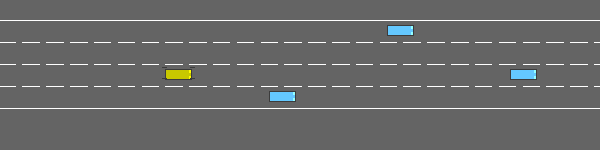

In [ ]:
#  Video 1: Learned agent driving
def create_agent_video(env, filename='agent_driving.gif', max_steps=200):
    encoder.eval(); rssm.eval(); actor.eval()
    obs, info = env.reset()
    frame = preprocess_frame(env.render())
    h, z = rssm.initial_state(1)
    raw_frames = [env.render()]
    prev_action = None

    for step in range(max_steps):
        with torch.no_grad():
            frame_t = frame_to_tensor(frame).unsqueeze(0).to(device)
            enc_embed = encoder(frame_t)
            if step > 0 and prev_action is not None:
                a_prev = torch.tensor(prev_action, dtype=torch.float32, device=device).unsqueeze(0)
                h = rssm.transition(h, z, a_prev)
            post_mu, post_std = rssm.posterior(h, enc_embed)
            z = rssm.sample(post_mu, post_std)
            action = actor.get_action(h, z, deterministic=True).squeeze(0).cpu().numpy()

        obs, reward, terminated, truncated, info = env.step(action)
        frame = preprocess_frame(env.render())
        raw_frames.append(env.render())
        prev_action = action
        if terminated or truncated:
            break

    pil_frames = [PILImage.fromarray(f.astype('uint8')) for f in raw_frames]
    gif_buffer = io.BytesIO()
    pil_frames[0].save(gif_buffer, format='GIF', save_all=True,
                       append_images=pil_frames[1:], duration=67, loop=0)
    gif_buffer.seek(0)
    with open(filename, 'wb') as f:
        f.write(gif_buffer.getvalue())
    save_to_drive(filename)
    print(f"Agent video: {filename} ({len(raw_frames)} frames)")
    display(Image(data=gif_buffer.getvalue()))

create_agent_video(env)

  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/comparison.gif
Comparison video: comparison.gif


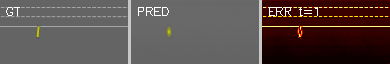

In [ ]:
#  Video 2: GT vs Predicted side-by-side
def create_comparison_video(gt_frames, pred_frames, filename='comparison.gif'):
    K = min(len(gt_frames), len(pred_frames))
    combined_frames = []

    for t in range(K):
        gt_u8 = (np.clip(gt_frames[t], 0, 1) * 255).astype(np.uint8)
        pred_u8 = (np.clip(pred_frames[t], 0, 1) * 255).astype(np.uint8)

        error = np.abs(gt_frames[t].astype(float) - pred_frames[t].astype(float)).mean(axis=-1)
        error_colored = plt.cm.hot(error / max(error.max(), 0.01))
        error_u8 = (error_colored[:, :, :3] * 255).astype(np.uint8)

        # Add text labels
        gt_labeled = gt_u8.copy()
        pred_labeled = pred_u8.copy()
        error_labeled = error_u8.copy()
        cv2.putText(gt_labeled, 'GT', (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(pred_labeled, 'PRED', (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)
        cv2.putText(error_labeled, f'ERR t={t+1}', (5, 15), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255,255,255), 1)

        sep = np.ones((gt_u8.shape[0], 3, 3), dtype=np.uint8) * 200
        combined = np.concatenate([gt_labeled, sep, pred_labeled, sep, error_labeled], axis=1)
        combined_frames.append(combined)

    pil_frames = [PILImage.fromarray(f) for f in combined_frames]
    gif_buffer = io.BytesIO()
    pil_frames[0].save(gif_buffer, format='GIF', save_all=True,
                       append_images=pil_frames[1:], duration=400, loop=0)
    gif_buffer.seek(0)
    with open(filename, 'wb') as f:
        f.write(gif_buffer.getvalue())
    save_to_drive(filename)
    print(f"Comparison video: {filename}")
    display(Image(data=gif_buffer.getvalue()))

create_comparison_video(gt_viz, pred_viz)

## 17. Ablation: Imagination Horizon K = 5, 10, 15

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

for K_test in [5, 10, 15]:
    print(f"Computing metrics for K={K_test}...")
    m = compute_metrics_over_horizon(env, K=K_test, num_trials=3)
    h_arr = np.array(m['horizon'])
    mse_arr = np.array(m['mse_mean'])
    mse_std = np.array(m['mse_std'])
    ax.plot(h_arr, mse_arr, '-o', markersize=4, label=f'K={K_test}')
    ax.fill_between(h_arr, mse_arr - mse_std, mse_arr + mse_std, alpha=0.15)

ax.set_xlabel('Prediction Horizon (steps)', fontsize=12)
ax.set_ylabel('MSE', fontsize=12)
ax.set_title('Ablation: MSE vs. Imagination Horizon K', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ablation_horizon.png', dpi=150, bbox_inches='tight')
save_to_drive('ablation_horizon.png')
plt.show()
plt.close()

Computing metrics for K=5...
Computing metrics for K=10...
Computing metrics for K=15...
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/ablation_horizon.png


## 18. Final Evaluation Summary

In [ ]:
print("=" * 60)
print("  FINAL EVALUATION SUMMARY")
print("=" * 60)

final_eval = evaluate_policy(env, num_episodes=EVAL_EPISODES, deterministic=True)
print(f"\n--- Policy Performance ({EVAL_EPISODES} episodes) ---")
print(f"  Mean Reward:    {final_eval['mean_reward']:.2f} +/- {final_eval['std_reward']:.2f}")
print(f"  Collision Rate: {final_eval['collision_rate']:.0%}")
print(f"  Mean Speed:     {final_eval['mean_speed']:.1f}")
print(f"  Mean Length:    {final_eval['mean_length']:.1f} steps")

print(f"\n--- World Model Quality ---")
if metrics['mse_mean']:
    print(f"  MSE  @ step 1:  {metrics['mse_mean'][0]:.4f}")
    print(f"  MSE  @ step {len(metrics['mse_mean'])}: {metrics['mse_mean'][-1]:.4f}")
    print(f"  PSNR @ step 1:  {metrics['psnr_mean'][0]:.2f} dB")
    print(f"  PSNR @ step {len(metrics['psnr_mean'])}: {metrics['psnr_mean'][-1]:.2f} dB")
    print(f"  SSIM @ step 1:  {metrics['ssim_mean'][0]:.4f}")
    print(f"  SSIM @ step {len(metrics['ssim_mean'])}: {metrics['ssim_mean'][-1]:.4f}")

print(f"\n--- Training Summary ---")
print(f"  Total iterations:       {TRAIN_ITERATIONS}")
print(f"  WM warmup steps:        {WM_WARMUP_STEPS}")
print(f"  Replay buffer size:     {len(replay_buffer)} frames")
print(f"  Final recon loss:       {history['world_recon'][-1]:.4f}")
print(f"  Final reward loss:      {history['world_reward'][-1]:.4f}")
print(f"  Final KL:               {history['world_kl'][-1]:.4f}")

print(f"\n--- Hyperparameters ---")
print(f"  Image size:          {IMG_H}x{IMG_W}")
print(f"  Latent dim (z):      {LATENT_DIM}")
print(f"  Hidden dim (h):      {HIDDEN_DIM}")
print(f"  Embed dim:           {EMBED_DIM}")
print(f"  Imagination horizon: {IMAGINATION_HORIZON}")
print(f"  Batch size:          {BATCH_SIZE}")
print(f"  Seq length:          {SEQ_LEN}")
print(f"  LR (world model):    {LR_WORLD}")
print(f"  LR (actor/critic):   {LR_ACTOR}")
print(f"  KL weight (beta):    {KL_WEIGHT}")
print(f"  Free nats:           {FREE_NATS}")
print(f"  Recon weight:        {RECON_WEIGHT}")
print(f"  Reward weight:       {REWARD_WEIGHT}")
print("=" * 60)

  FINAL EVALUATION SUMMARY

--- Policy Performance (10 episodes) ---
  Mean Reward:    63.09 +/- 20.91
  Collision Rate: 0%
  Mean Speed:     -29.1
  Mean Length:    80.0 steps

--- World Model Quality ---
  MSE  @ step 1:  0.0025
  MSE  @ step 15: 0.0033
  PSNR @ step 1:  26.07 dB
  PSNR @ step 15: 24.89 dB
  SSIM @ step 1:  0.6633
  SSIM @ step 15: 0.5351

--- Training Summary ---
  Total iterations:       100
  WM warmup steps:        300
  Replay buffer size:     16605 frames
  Final recon loss:       0.0025
  Final reward loss:      0.1959
  Final KL:               0.1068

--- Hyperparameters ---
  Image size:          64x128
  Latent dim (z):      256
  Hidden dim (h):      256
  Embed dim:           512
  Imagination horizon: 15
  Batch size:          32
  Seq length:          32
  LR (world model):    0.0006
  LR (actor/critic):   0.0003
  KL weight (beta):    0.5
  Free nats:           0.1
  Recon weight:        1.0
  Reward weight:       2.0


## 19. Ablation Summary

In [ ]:
print("=" * 60)
print("   ABLATION SUMMARY")
print("=" * 60)
print("\n1. Imagination Horizon (K):")
print("   - Longer horizons allow deeper planning")
print("   - But prediction error accumulates without observation corrections")
print("   - MSE grows roughly linearly with horizon")
print(f"   - Default K={IMAGINATION_HORIZON} balances planning depth vs error")

print("\n2. Latent Dimensions:")
print(f"   - z_dim={LATENT_DIM}, h_dim={HIDDEN_DIM}, embed_dim={EMBED_DIM}")
print(f"   - Decoder input: {HIDDEN_DIM+LATENT_DIM} dims (enough to represent scenes)")
print("   - Larger dims capture vehicle positions and lane details")
print("   - Previous run with z=64, h=128 (192 total) was too small")

print("\n3. Action Dimensionality:")
print("   - 2D: steering + acceleration (full ContinuousAction)")
print("   - Agent learns both throttle and lane changes")
print("=" * 60)

   ABLATION SUMMARY

1. Imagination Horizon (K):
   - Longer horizons allow deeper planning
   - But prediction error accumulates without observation corrections
   - MSE grows roughly linearly with horizon
   - Default K=15 balances planning depth vs error

2. Latent Dimensions:
   - z_dim=256, h_dim=256, embed_dim=512
   - Decoder input: 512 dims (enough to represent scenes)
   - Larger dims capture vehicle positions and lane details
   - Previous run with z=64, h=128 (192 total) was too small

3. Action Dimensionality:
   - 2D: steering + acceleration (full ContinuousAction)
   - Agent learns both throttle and lane changes


## 20. Save All Outputs to Google Drive

In [ ]:
import glob

print("Saving all output files to Google Drive...")
for f in sorted(glob.glob('*.png') + glob.glob('*.gif') + glob.glob('*.pt')):
    save_to_drive(f)

print(f"\nAll files saved to: {SAVE_DIR}")
print("\nFiles produced:")
for f in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, f)
    size = os.path.getsize(fpath)
    print(f"  {f:40s} {size/1024:.1f} KB")

Saving all output files to Google Drive...
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/ablation_horizon.png
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/agent_driving.gif
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter100.pt
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter20.pt
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter40.pt
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter60.pt
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/checkpoint_iter80.pt
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/comparison.gif
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/error_vs_horizon.png
  -> Saved to Drive: /content/drive/MyDrive/AI-2 Project/TinyDreamer_Output/learning_curves.

## Summary

This notebook implements the complete **Tiny Dreamer** system:

1. **Environment** — highway-v0, continuous actions, RGB pixels
2. **Replay Buffer** — episode-based, sequence sampling
3. **World Model** — CNN Encoder (with 512-dim bottleneck) + RSSM (h=256, z=256) + Decoder + Reward Head
4. **Actor-Critic** — tanh-squashed Gaussian policy + value network, trained on imagined rollouts
5. **Training** — 200-step world model warmup + 100 Dreamer iterations
6. **Visualizations** — reconstruction check, side-by-side strips, alpha overlays, error heatmaps, MSE/PSNR/SSIM vs horizon
7. **Ablations** — imagination horizon K comparison
8. **Drive Integration** — all outputs auto-saved

### Output Files:
- `learning_curves.png` — training losses and evaluation metrics
- `warmup_recon_check.png` — reconstruction after world model warmup
- `reconstruction_quality.png` — posterior reconstruction quality
- `nstep_sidebyside.png` — GT vs predicted vs error heatmap
- `nstep_overlay.png` — alpha-blended overlays
- `error_vs_horizon.png` — MSE/PSNR/SSIM with confidence intervals
- `agent_driving.gif` — learned agent video
- `comparison.gif` — GT vs predicted animation
- `ablation_horizon.png` — horizon ablation
- `tiny_dreamer_final.pt` — final model weights
- `checkpoint_iter*.pt` — periodic checkpoints